In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    auc
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import time

from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## Step 1: Data Preparation

In [2]:
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 

raw_df = pd.concat([X, y], axis=1)
raw_df.columns = [
    "age", "job", "marital", "education", "default", "balance", "housing", "loan", "contact",
    "day_of_week", "month", "duration", "campaign", "pdays", "previous", "poutcome", "y"
]

print("Shape:", raw_df.shape)
raw_df.head()

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [3]:
stats = []
total_rows = len(raw_df)

for col in raw_df.columns:
    nan_count = raw_df[col].isna().sum()
    unknown_count = (raw_df[col] == "unknown").sum() if raw_df[col].dtype == 'object' else 0
    total_missing = nan_count + unknown_count
    missing_pct = (total_missing / total_rows) * 100
    
    stats.append({
        "Column": col,
        "NaN": nan_count,
        "Unknown": unknown_count,
        "Total": total_missing,
        "Pct(%)": round(missing_pct, 2)
    })

print("--- Data Missing Values Report ---")
print(pd.DataFrame(stats))
print("-" * 30)

df_cleaned = raw_df.copy()
stats_df = pd.DataFrame(stats)

# 'pdays' is converted to binary feature 'is_previously_contacted', and then dropped
df_cleaned['is_previously_contacted'] = (df_cleaned['pdays'] != -1).astype(int)
df_cleaned.drop(columns=['pdays'], inplace=True)
print("✓ Feature Engineering: 'pdays' converted to 'is_previously_contacted' and dropped.")

# 'duration' is dropped to prevent target leakage
if 'duration' in df_cleaned.columns:
    df_cleaned.drop(columns=['duration'], inplace=True)
    print("✓ Dropped 'duration' to prevent target leakage.")

# 'poutcome' missing values unified to 'nonexistent'
if 'poutcome' in df_cleaned.columns:
    df_cleaned['poutcome'] = df_cleaned['poutcome'].replace(["unknown", np.nan], "nonexistent")
    print("✓ 'poutcome' missing values unified to 'nonexistent'.")

exclude_cols = ['duration', 'pdays', 'poutcome']
process_mask = ~stats_df['Column'].isin(exclude_cols)

# < 5%: regular category 'unknown'
low_cols = stats_df[process_mask & (stats_df['Total'] > 0) & (stats_df['Pct(%)'] < 5)]['Column'].tolist()
for col in low_cols:
    df_cleaned[col] = df_cleaned[col].replace("unknown", "unknown").fillna("unknown")
if low_cols: print(f"✓ Low missing (<5%) handled as 'unknown' category: {low_cols}")

# 5% - 30%: convert 'unknown' to NaN for imputation
mid_cols = stats_df[process_mask & (stats_df['Pct(%)'] >= 5) & (stats_df['Pct(%)'] < 30)]['Column'].tolist()
for col in mid_cols:
    df_cleaned[col] = df_cleaned[col].replace("unknown", np.nan)
if mid_cols: print(f"✓ Mid missing (5%-30%) converted to NaN for Imputation: {mid_cols}")

print("-" * 30)
print(f"Final Cleaned Shape: {df_cleaned.shape}")

--- Data Missing Values Report ---
         Column    NaN  Unknown  Total  Pct(%)
0           age      0        0      0    0.00
1           job    288        0    288    0.64
2       marital      0        0      0    0.00
3     education   1857        0   1857    4.11
4       default      0        0      0    0.00
5       balance      0        0      0    0.00
6       housing      0        0      0    0.00
7          loan      0        0      0    0.00
8       contact  13020        0  13020   28.80
9   day_of_week      0        0      0    0.00
10        month      0        0      0    0.00
11     duration      0        0      0    0.00
12     campaign      0        0      0    0.00
13        pdays      0        0      0    0.00
14     previous      0        0      0    0.00
15     poutcome  36959        0  36959   81.75
16            y      0        0      0    0.00
------------------------------
✓ Feature Engineering: 'pdays' converted to 'is_previously_contacted' and dropped.
✓ Dro

In [4]:
set_config(transform_output="pandas")

df_cleaned['y'] = (df_cleaned['y'].astype(str).str.strip() == 'yes').astype(int)

X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

print("Final feature set shape:", X.shape)
print("Final feature columns:", X.columns.tolist())

Final feature set shape: (45211, 15)
Final feature columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'previous', 'poutcome', 'is_previously_contacted']


In [5]:
# Train-Validation-Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 31647
Validation size: 6782
Test size: 6782


In [6]:
# Preprocessing
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# GBDT Preprocessing Pipeline
# XGBoost handles missing values and categorical features natively if they are pandas 'category' type.
X_train_gbdt = X_train.copy()
X_val_gbdt = X_val.copy()
X_test_gbdt = X_test.copy()

for col in categorical_cols:
    X_train_gbdt[col] = X_train_gbdt[col].astype('category')
    X_val_gbdt[col] = X_val_gbdt[col].astype('category')
    X_test_gbdt[col] = X_test_gbdt[col].astype('category')

feature_names_xgb = X_train_gbdt.columns.tolist()

# MLP Preprocessing Pipeline
# MLP requires strictly numerical, scaled data without missing values, so we will impute, encode, and scale the features.
numeric_transformer_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_mlp = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_mlp = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_mlp, numeric_cols),
        ('cat', categorical_transformer_mlp, categorical_cols)
    ],
    verbose_feature_names_out=False
)


X_train_mlp = preprocessor_mlp.fit_transform(X_train)
X_val_mlp = preprocessor_mlp.transform(X_val)
X_test_mlp = preprocessor_mlp.transform(X_test)

## Step 2: Gradient Boosted Tree (GBDT)

In [7]:
# Scale position weight for GBDT
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated pos_weight for XGBoost: {pos_weight:.2f}")

Calculated pos_weight for XGBoost: 7.55


In [8]:
# Create a baseline model with native categorical support
xgb_baseline = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    enable_categorical=True,
    scale_pos_weight=pos_weight     # Deal with class imbalance
)

xgb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_baseline,
    param_distributions=xgb_param_grid,
    scoring='f1',
    n_iter=30,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search_xgb.fit(X_train_gbdt, y_train)
xgb_tune_time = time.time() - start_time

print(f"Best Parameters: {random_search_xgb.best_params_}")
best_params = random_search_xgb.best_params_

print(f"XGBoost Tuning Time: {xgb_tune_time:.2f} seconds")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best Parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}
XGBoost Tuning Time: 15.05 seconds


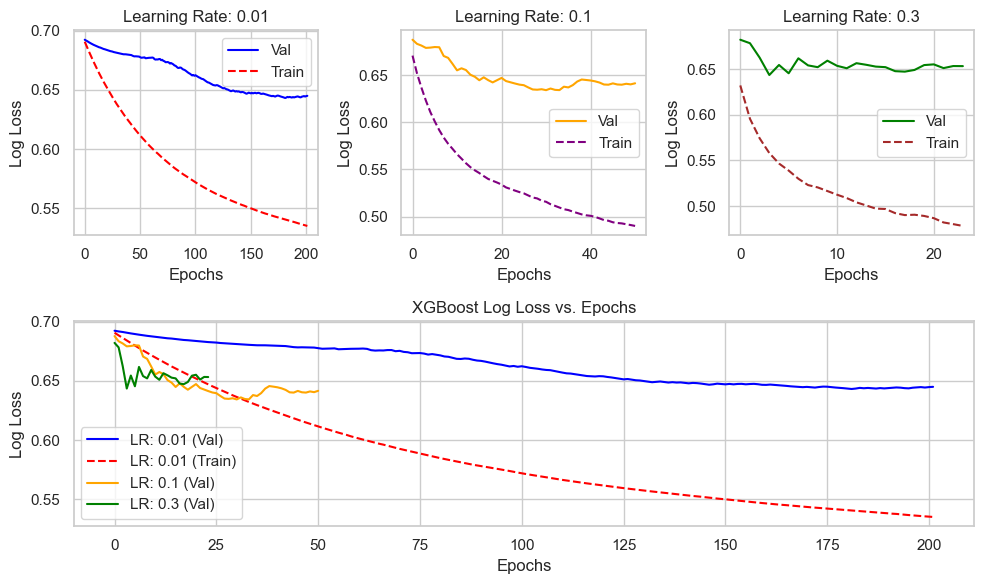

In [9]:
learning_rates = [0.01, 0.1, 0.3]

plt.figure(figsize=(10, 6))
axes = [plt.subplot2grid((2, 3), (0, 0)), plt.subplot2grid((2, 3), (0, 1)), plt.subplot2grid((2, 3), (0, 2))]
ax = plt.subplot2grid((2, 3), (1, 0), colspan=3)

colors_val = ['blue', 'orange', 'green']
colors_train = ['red', 'purple', 'brown']

for i in range(len(learning_rates)):
    lr = learning_rates[i]
    params = best_params.copy()
    params['learning_rate'] = lr
    params['n_estimators'] = 1000
    
    model = xgb.XGBClassifier(**params, random_state=42, enable_categorical=True, early_stopping_rounds=20, scale_pos_weight=pos_weight)
    
    eval_set = [(X_train_gbdt, y_train), (X_val_gbdt, y_val)]
    model.fit(
        X_train_gbdt, y_train, 
        eval_set=eval_set, 
        verbose=False
    )
    
    results = model.evals_result()
    train_loss = results['validation_0']['logloss']
    val_loss = results['validation_1']['logloss']
    epochs = len(val_loss)
    x_axis = range(0, epochs)
    
    axes[i].plot(x_axis, val_loss, label=f'Val', color=colors_val[i])
    axes[i].plot(x_axis, train_loss, label=f'Train', color=colors_train[i], linestyle='--')
    axes[i].set_title(f'Learning Rate: {lr}')
    axes[i].set_ylabel('Log Loss')
    axes[i].set_xlabel('Epochs')
    axes[i].legend()
    ax.plot(x_axis, val_loss, label=f'LR: {lr} (Val)', color=colors_val[i])
    
    if lr == best_params['learning_rate']:
        final_xgb_model = model
        ax.plot(x_axis, train_loss, label=f'LR: {lr} (Train)', color=colors_train[i], linestyle='--')

ax.set_title('XGBoost Log Loss vs. Epochs')
ax.set_xlabel('Epochs')
ax.set_ylabel('Log Loss')
ax.legend()
plt.tight_layout()
plt.show()

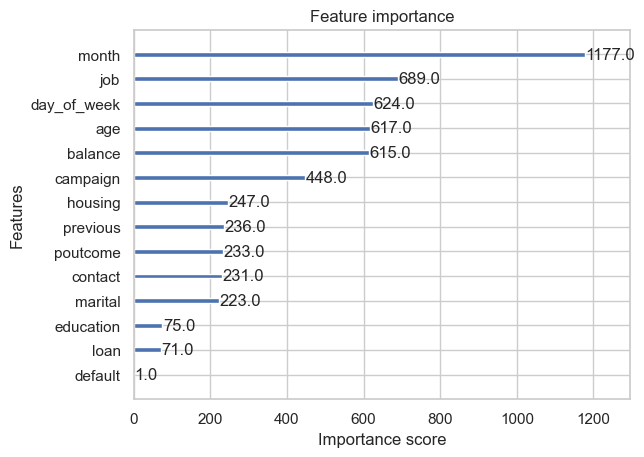

In [13]:
xgb.plot_importance(final_xgb_model)
plt.show()

## Step 3: Multi-Layer Perceptron (MLP)

In [14]:
mlp_baseline = MLPClassifier(random_state=42, early_stopping=False)

mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [50, 100, 200]
}

random_search_mlp = RandomizedSearchCV(
    estimator=mlp_baseline,
    param_distributions=mlp_param_grid,
    n_iter=30,
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search_mlp.fit(X_train_mlp, y_train)
mlp_tune_time = (time.time() - start_time)

print(f"Best Parameters for MLP: {random_search_mlp.best_params_}")
final_mlp_model = random_search_mlp.best_estimator_

print(f"MLP Tuning Time: {mlp_tune_time:.2f} seconds")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters for MLP: {'max_iter': 50, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'activation': 'relu'}
MLP Tuning Time: 273.68 seconds


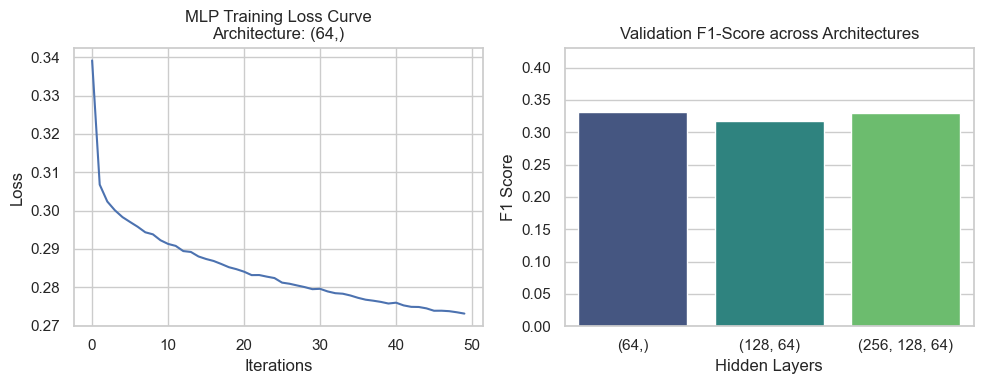

In [15]:
architectures = [(64,), (128, 64), (256, 128, 64)]
arch_names = ['(64,)', '(128, 64)', '(256, 128, 64)']
val_scores = []

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(final_mlp_model.loss_curve_)
plt.title(f'MLP Training Loss Curve\nArchitecture: {final_mlp_model.hidden_layer_sizes}')
plt.xlabel('Iterations')
plt.ylabel('Loss')

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch, 
        activation=final_mlp_model.activation,
        learning_rate_init=final_mlp_model.learning_rate_init,
        max_iter=final_mlp_model.max_iter,
        random_state=42,
        early_stopping=False
    )
    model.fit(X_train_mlp, y_train)
    
    y_val_pred = model.predict(X_val_mlp)
    val_scores.append(f1_score(y_val, y_val_pred))

plt.subplot(1, 2, 2)
sns.barplot(x=arch_names, y=val_scores, palette='viridis')
plt.title('Validation F1-Score across Architectures')
plt.xlabel('Hidden Layers')
plt.ylabel('F1 Score')
plt.ylim(0, max(val_scores) + 0.1)

plt.tight_layout()
plt.show()

## Step 4: GBDT vs MLP Comparison

In [16]:
y_pred_xgb = final_xgb_model.predict(X_test_gbdt)
y_prob_xgb = final_xgb_model.predict_proba(X_test_gbdt)[:, 1]

y_pred_mlp = final_mlp_model.predict(X_test_mlp)
y_prob_mlp = final_mlp_model.predict_proba(X_test_mlp)[:, 1]

def evaluate_model(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    auc_pr = auc(recall, precision)
    
    return acc, prec, rec, f1, auc_pr

metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_prob_xgb)
metrics_mlp = evaluate_model(y_test, y_pred_mlp, y_prob_mlp)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-PR', 'Tuning Time (s)'],
    'GBDT (XGBoost)': list(metrics_xgb) + [xgb_tune_time],
    'MLP': list(metrics_mlp) + [mlp_tune_time]
})

print(comparison_df.round(4))

            Metric  GBDT (XGBoost)       MLP
0         Accuracy          0.8459    0.8928
1        Precision          0.3899    0.6187
2           Recall          0.5624    0.2169
3         F1-Score          0.4605    0.3212
4           AUC-PR          0.4347    0.4071
5  Tuning Time (s)         15.0500  273.6769


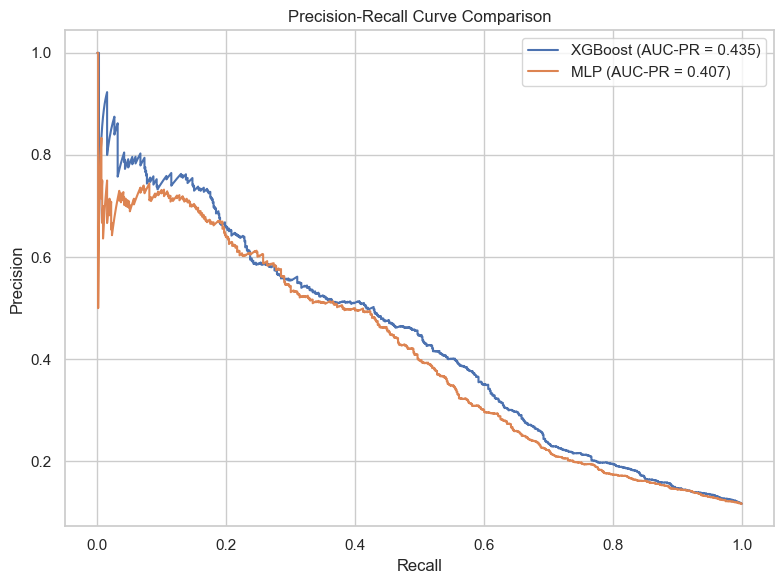

In [17]:
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUC-PR = {comparison_df.iloc[4, 1]:.3f})')
plt.plot(recall_mlp, precision_mlp, label=f'MLP (AUC-PR = {comparison_df.iloc[4, 2]:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Discussion

- When would you prefer GBDT over MLP, and vice versa?
  
  For tabular data like this bank dataset, I would prefer GBDT because it is more efficient at finding patterns and split data in structured columns. I would switch to MLP if the data was unstructured and continuous, such as images or voice, where deep learning is necessary to extract features.

- How does interpretability differ? (GBDT has feature importance; MLP is a black box)
  
  GBDT is much easier to explain because we can use "Feature Importance" to see exactly which of the features affected the result more, and which of them barely contribute. In contrast, an MLP is a "black box" where the decision logic is hidden inside many layers, making it hard to trust for business decisions.

- How does each model handle categorical features and missing values?
  
  GBDT is very convenient because it can handle NaN values and categorical labels automatically during the tree-splitting process. However, MLP is much more strict. It requires me to manually fill all missing values (imputation) and convert categories into numbers (one-hot encoding) before training.

- Which model is more sensitive to hyperparameter choices?
  
  The MLP is much more sensitive. if the learning rate or the number of hidden layers is slightly wrong, the model might not converge at all. GBDT is more robust and usually gives a decent baseline score even with default settings, making it easier to tune in a short time.
